In [44]:
from pathlib import Path
notebook_dir = Path().resolve()
data_path = notebook_dir.parent / "img" / "secom.csv"
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import datetime as dt
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Microsoft JhengHei'  # or 'Noto Sans TC'
plt.rcParams['axes.unicode_minus'] = False
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from scipy import stats as sps
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, accuracy_score, f1_score, r2_score, mean_absolute_error, mean_squared_error
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier


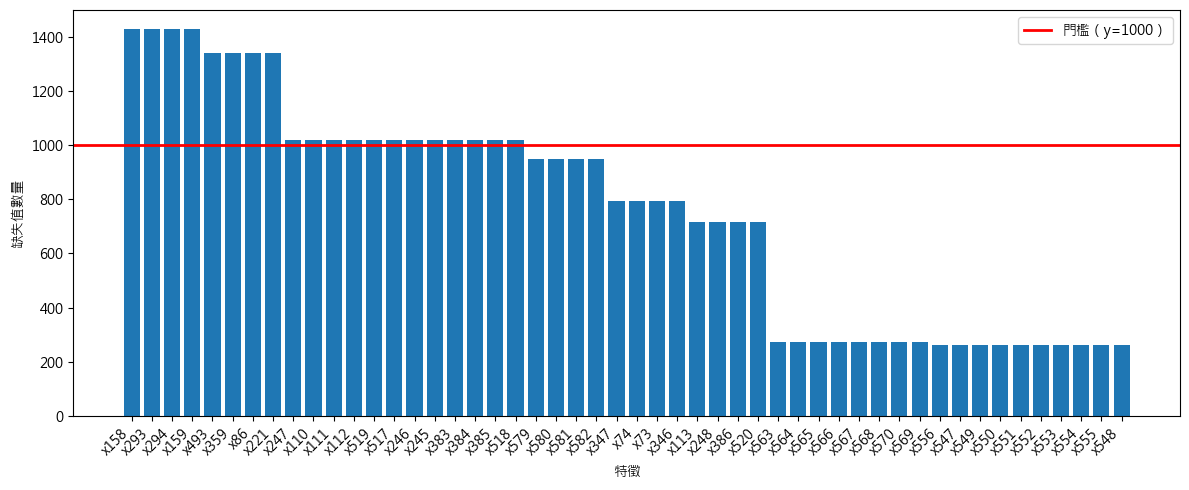

In [47]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1: 0, 1: 1}).astype(int)

na_cnt = X.isna().sum().sort_values(ascending=False)

topk = 50
na_top = na_cnt.head(topk)
x_ticks = na_top.index.tolist()

plt.figure(figsize=(12, 5))
plt.bar(range(len(na_top)), na_top.values)
plt.xticks(range(len(na_top)), x_ticks, rotation=45, ha='right')
plt.axhline(y=1000, color='r', linewidth=2, label='門檻（y=1000）')
plt.xlabel("特徵")
plt.ylabel("缺失值數量")
plt.legend()
plt.tight_layout()
plt.show()

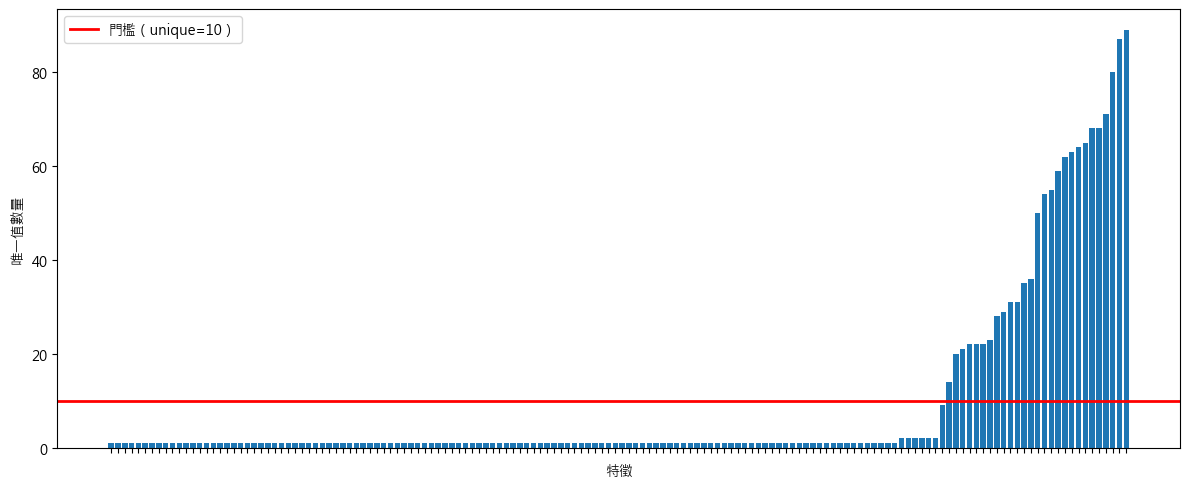

In [6]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()

uniq_counts = X.nunique(dropna=True).sort_values(ascending=True)

topk = 150
na_top = uniq_counts.head(topk)
x_ticks = na_top.index.tolist()

plt.figure(figsize=(12, 5))
plt.bar(range(len(na_top)), na_top.values)
plt.xticks(ticks=range(len(na_top)), labels=[''] * len(na_top))
plt.axhline(y=10, color='r', linewidth=2, label='門檻（unique=10）')

plt.xlabel("特徵")
plt.ylabel("唯一值數量")
plt.legend()
plt.tight_layout()
plt.show()

PCA 保留 131 個主成分


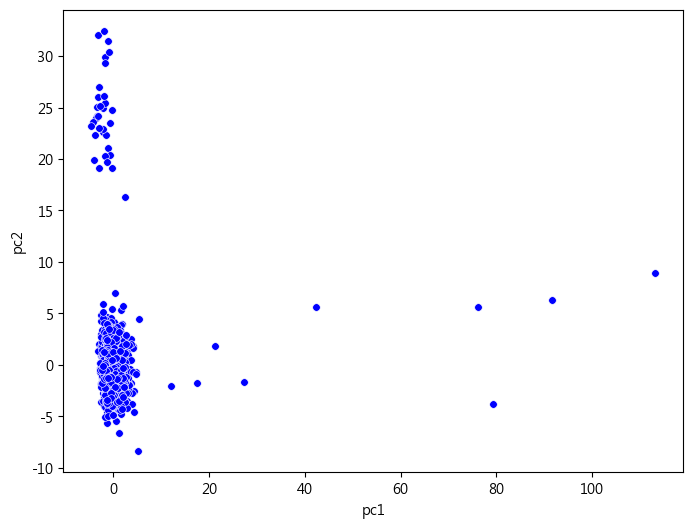

In [2]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', s=30, color='b')
plt.show()

PCA 保留 131 個主成分
cluster sizes: {0: 1563, 1: 4}
cluster     0  1
y               
0        1460  3
1         103  1


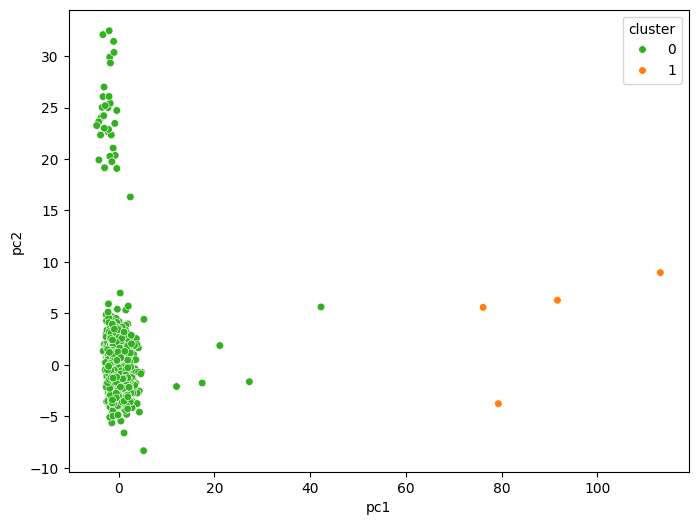

In [39]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['cluster'] = labels

plt.figure(figsize=(8,6))
palette = {
    0: "#33B020",  # cluster 0, y=1
    1: '#ff7f0e',  # cluster 1, y=0
}
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='cluster', s=30, palette=palette)
plt.show()

PCA 保留 126 個主成分
cluster sizes: {0: 60, 1: 2134}
cluster   0     1
y                
0        25  1438
1        35   696


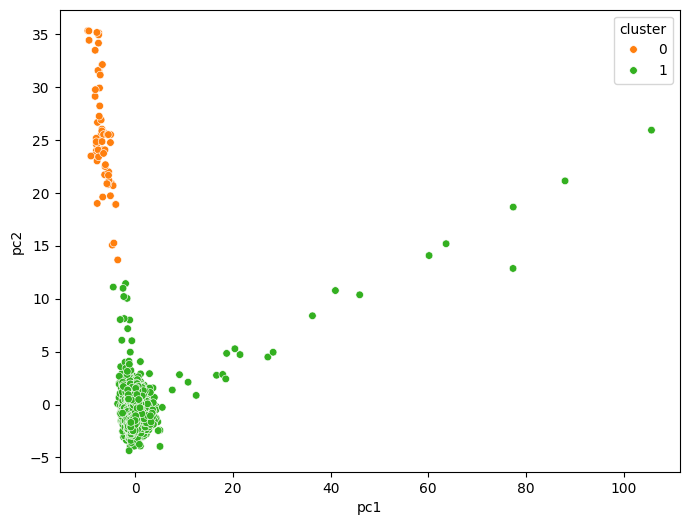

In [ ]:
secom = pd.read_csv(data_path, sep='\t')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=0.5, k_neighbors=10)
X_smote, y_smote = smote.fit_resample(X_std, y)
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_smote_df)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y_smote.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['cluster'] = labels

plt.figure(figsize=(8,6))
palette = {
    1: "#33B020",  # cluster 0, y=1
    0: '#ff7f0e',  # cluster 1, y=0
}
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='cluster', s=30, palette=palette)
plt.show()

In [10]:
X_std

,x1,x2,x3,x4,x5,x7,x8,x9,x10,x11,...,x581,x582,x583,x584,x585,x586,x587,x588,x589,x590
0,0.216411,0.856549,-0.434551,0.023500,-0.051987,-0.546749,0.256173,0.521406,1.121315,-0.372980,...,-0.349291,-0.220985,0.120331,-0.202448,-0.091826,-0.194761,-0.278654,-0.140893,-0.050083,0.201450
1,1.094037,-0.374751,1.020782,0.142049,-0.061313,0.209791,0.307169,0.468613,0.014491,-1.603007,...,0.288903,2.006795,0.532455,0.401942,0.439739,0.380511,-0.960619,0.421933,0.258167,1.167895
2,-1.114171,0.805982,-0.479627,0.670902,-0.049351,-0.886712,0.245974,-0.248829,0.319365,0.134136,...,4.526034,-0.164680,-1.263228,0.022039,0.014487,0.029495,2.972233,3.631596,3.316370,-0.171694
3,-0.354825,-0.190915,-0.049316,-1.107818,-0.052686,0.512631,0.001194,0.354905,-0.774204,-0.362190,...,-0.481485,-0.320891,-0.321230,-0.288790,-0.357609,-0.280042,-0.106352,-0.167828,-0.297870,-0.268061
4,0.234139,0.095176,1.121165,-0.167425,-0.048944,-0.101558,0.184779,0.556601,-0.157829,-0.782989,...,0.094126,0.424783,-5.914343,26.551870,26.752218,26.594405,-0.106352,-0.167828,-0.297870,-0.268061
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1520,-1.563472,-0.384465,-0.707284,3.801642,-0.049806,-3.004559,0.317368,-1.618736,-0.250616,-0.621144,...,-0.337037,1.919611,-0.380105,-0.058546,0.014487,-0.055510,-1.186275,-0.292585,-0.193613,1.114111
1521,0.505750,0.340290,-0.065223,-0.622946,-0.060489,-0.409900,-0.121197,-0.388256,-0.356659,-1.009573,...,0.428640,0.356134,-0.762792,-0.127619,-0.065248,-0.122690,-1.186275,-0.292585,-0.193613,1.114111
1522,-0.488938,-1.437908,0.198417,-0.654906,-0.061415,-0.259024,-0.090599,0.295257,-0.215528,-0.411018,...,-1.396320,-0.846159,-0.409543,-0.000985,0.067643,-0.002423,-0.146648,-0.882347,-0.958164,-0.592100
1523,-1.624236,0.458114,-0.799332,-0.489650,-0.048255,-0.357294,-0.039603,0.002953,-0.429564,0.339141,...,1.011141,0.019543,0.090894,0.142917,-0.012091,0.137740,0.377195,0.920962,0.779451,-0.058046


PCA 保留 137 個主成分


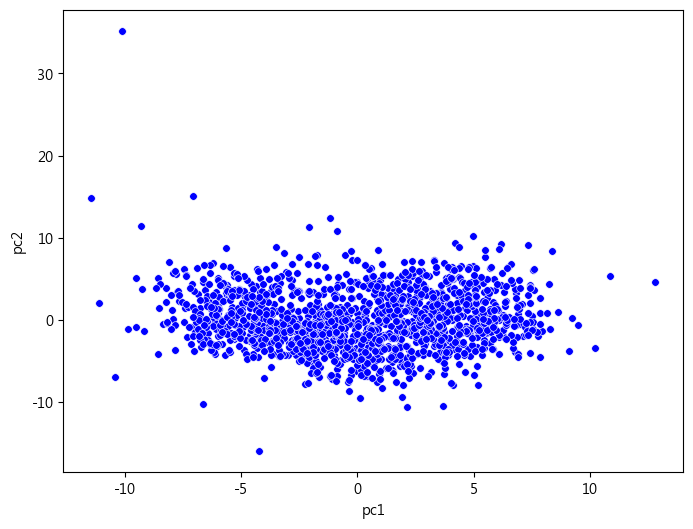

In [3]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', s=30, color='b')
plt.show()

PCA 保留 137 個主成分
cluster sizes: {0: 718, 1: 807}
cluster    0    1
y                
0        660  770
1         58   37


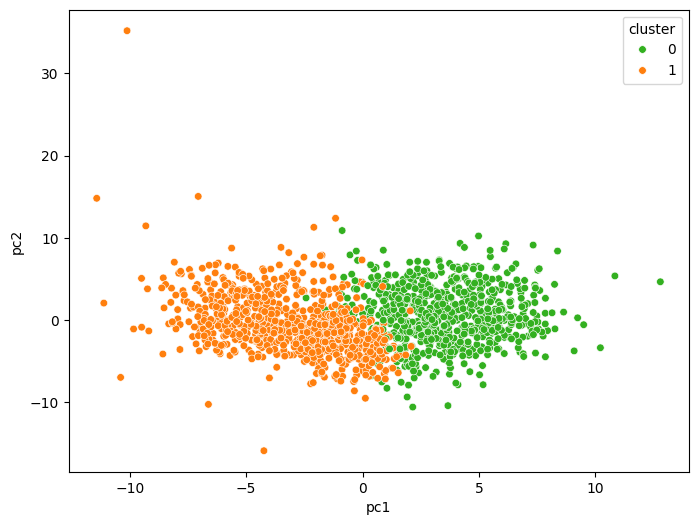

In [38]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['cluster'] = labels

plt.figure(figsize=(8,6))
palette = {
    0: "#33B020",  # cluster 0, y=1
    1: '#ff7f0e',  # cluster 1, y=0
}
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='cluster', s=30, palette=palette)
plt.show()

PCA 保留 125 個主成分


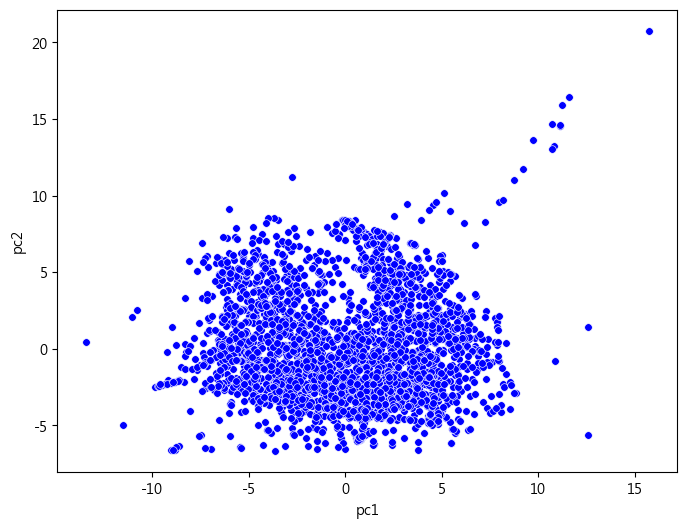

In [11]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_std, y)
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_smote_df)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

plt.figure(figsize=(8,6))
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', s=30, color='b')
plt.show()

PCA 保留 125 個主成分


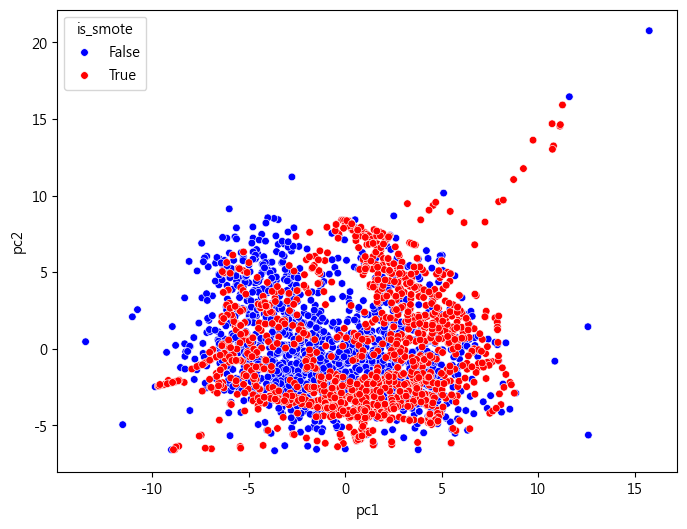

In [16]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
# 1) 在 SMOTE 後保留 index（最低限度修改：只加這兩行）
X_smote, y_smote = smote.fit_resample(X_std, y)
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns, index=X_smote.index)

# 2) PCA 後把「是否為合成樣本」帶到投影空間
pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_smote_df)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)], index=X_smote_df.index)

# 3) 合成樣本判定：SMOTE 新增的那些 index 不在原始 X_std.index
X_pca_df['is_smote'] = ~X_pca_df.index.isin(X_std.index)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=X_pca_df, x='pc1', y='pc2',
    hue='is_smote', palette={False:'b', True:'r'},
    s=30, legend=True
)
plt.show()


PCA 保留 125 個主成分
cluster sizes: {0: 1548, 1: 1312}
cluster    0    1
y                
0        619  811
1        929  501


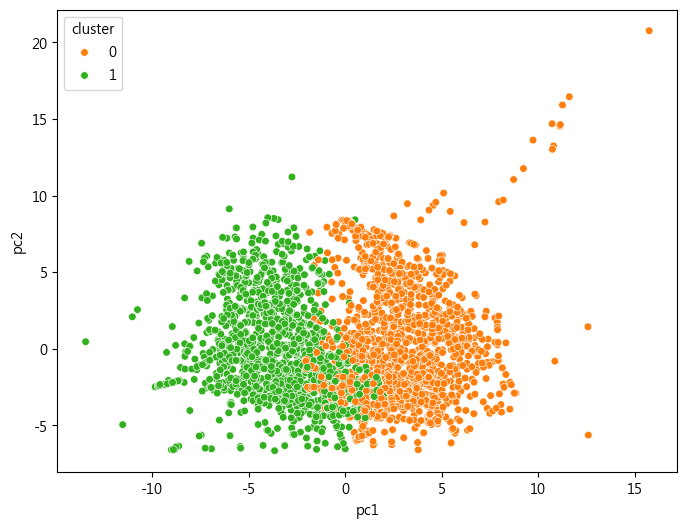

In [13]:
secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_std, y)
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_smote_df)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y_smote.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['cluster'] = labels

plt.figure(figsize=(8,6))
palette = {
    1: "#33B020",  # cluster 0, y=1
    0: '#ff7f0e',  # cluster 1, y=0
}
sns.scatterplot(data=X_pca_df, x='pc1', y='pc2', hue='cluster', s=30, palette=palette)
plt.show()

PCA 保留 125 個主成分
cluster sizes: {0: 1548, 1: 1312}
cluster    0    1
y                
0        619  811
1        929  501


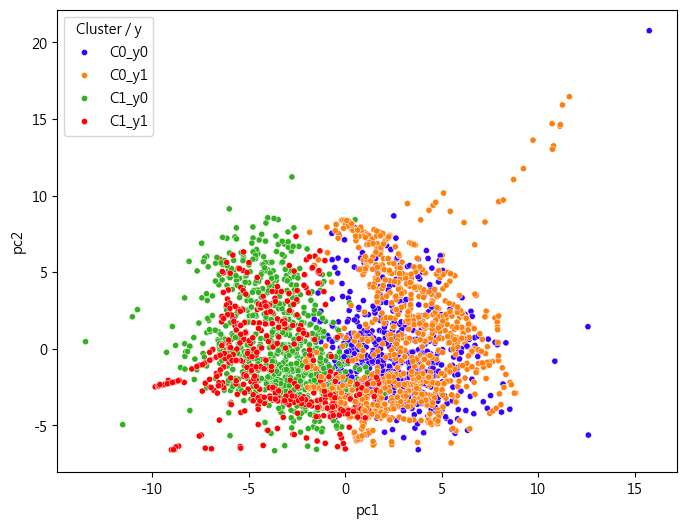

In [ ]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_std, y)
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_smote_df)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
labels = kmeans.fit_predict(X_pca)
sizes = pd.Series(labels).value_counts().sort_index()
print('cluster sizes:', sizes.to_dict())

df = pd.DataFrame({'y': y_smote.values, 'label': labels})

ct = pd.crosstab(df['y'], df['label'], rownames=['y'], colnames=['cluster'])
print(ct)

X_pca_df['cluster'] = labels

X_pca_df['y'] = y_smote.values

# 建一個 4 類別欄位： (cluster, y)
X_pca_df['group'] = (
    'C' + X_pca_df['cluster'].astype(str) + '_y' + X_pca_df['y'].astype(str)
)
# 這樣會有：C0_y0, C0_y1, C1_y0, C1_y1 四種

plt.figure(figsize=(8,6))
# 自訂 4 種顏色（可自行調整）
palette = {
    'C0_y0': "#3700ff",  # cluster 0, y=0
    'C0_y1': '#ff7f0e',  # cluster 0, y=1
    'C1_y0': "#33B020",  # cluster 1, y=0
    'C1_y1': "#ff0000",  # cluster 1, y=1
}
sns.scatterplot(
    data=X_pca_df,
    x='pc1', y='pc2',
    hue='group',
    palette=palette,
    s=20
)
plt.legend(title='Cluster / y', loc='best')
plt.show()

PCA 保留 125 個主成分
PCA 保留 125 個主成分（以原始資料繪圖）
cluster sizes (original only): {0: 676, 1: 849}
cluster    0    1
y                
0        619  811
1         57   38


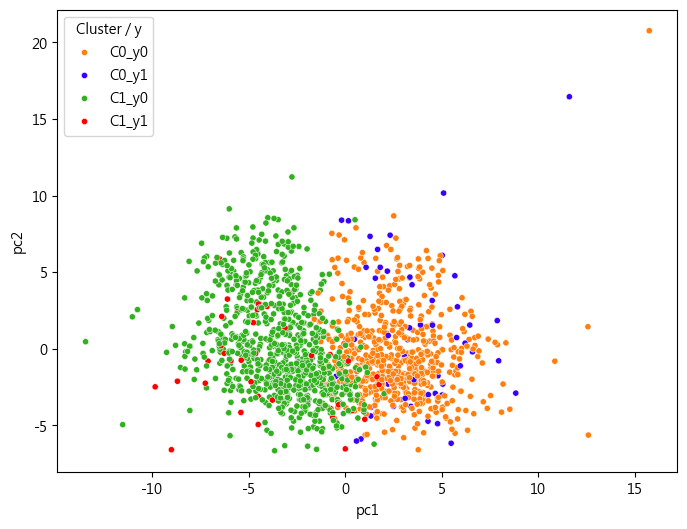

In [5]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_std, y)
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_smote_df)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
# 只取「原始資料」的 PCA 座標（用 X_std，不用 X_smote_df）
X_pca_org = pca.transform(X_std)
print(f'PCA 保留 {X_pca_org.shape[1]} 個主成分（以原始資料繪圖）')
X_pca_org_df = pd.DataFrame(
    X_pca_org,
    columns=[f'pc{i}' for i in range(1, X_pca_org.shape[1] + 1)],
    index=X_std.index
)

# --- KMeans：用 SMOTE 的 PCA 空間 fit（保持你原本分群依據），再對原始資料 predict ---
X_pca_smote = pca.transform(X_smote_df)
kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
kmeans.fit(X_pca_smote)

labels_org = kmeans.predict(X_pca_org)  # 原始樣本的 cluster
sizes = pd.Series(labels_org).value_counts().sort_index()
print('cluster sizes (original only):', sizes.to_dict())

# --- 列聯表：只用原始樣本（y 與 labels_org 長度一致） ---
df_org = pd.DataFrame({'y': y.values, 'label': labels_org})
ct = pd.crosstab(df_org['y'], df_org['label'], rownames=['y'], colnames=['cluster'])
print(ct)

# --- 繪圖資料：只含原始樣本 ---
X_pca_org_df['cluster'] = labels_org
X_pca_org_df['y'] = y.values
X_pca_org_df['group'] = (
    'C' + X_pca_org_df['cluster'].astype(str) + '_y' + X_pca_org_df['y'].astype(str)
)

plt.figure(figsize=(8, 6))
palette = {
    'C0_y0': '#ff7f0e',  # cluster 0, y=0
    'C0_y1': "#3700ff",  # cluster 0, y=1
    'C1_y0': "#33B020",  # cluster 1, y=0
    'C1_y1': "#ff0000",  # cluster 1, y=1
}
sns.scatterplot(data=X_pca_org_df, x='pc1', y='pc2', hue='group', s=20, palette=palette)
plt.legend(title='Cluster / y', loc='best')
plt.show()

In [4]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
print(f'PCA 保留 {X_pca.shape[1]} 個主成分')
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()
secom = secom.drop(index=outlier).reset_index(drop=True)
print(f'PCA極端值有:{outlier}, \n共{len(outlier)}個')
X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
X_smote, y_smote = smote.fit_resample(X_std, y)

# X_smote, y_smote 已經是你前面做完 SMOTE 後的標準化空間資料
X_smote_df = pd.DataFrame(X_smote, columns=X_std.columns)

# 1) 在同一個 SMOTE 空間做 PCA + KMeans，得到 cluster
pca = PCA(n_components=0.9, random_state=42)
X_pca = pca.fit_transform(X_smote_df)
n_real = len(X_std)

# 必要斷言：確保前段就是原始點
assert np.allclose(X_smote_df.iloc[:n_real].values, X_std.values, atol=0, rtol=0)
assert np.array_equal(np.asarray(y_smote)[:n_real], np.asarray(y))

kmeans = KMeans(n_clusters=2, n_init=10, max_iter=300, random_state=42)
cluster = kmeans.fit_predict(X_pca)

# X_smote_df 目前包含所有特徵 + "cluster"
X_smote_df["cluster"] = cluster

# 確保 X_all_df 不含 cluster 欄
X_feat_df = X_smote_df.drop(columns=["cluster"]).copy()
# 只取真實點（不含 SMOTE 合成點）來做 local surrogate 與訓練每群 blackbox
X_all_df = X_feat_df.iloc[:n_real].copy() # 真實點特徵（標準化空間）
c_all = X_smote_df.loc[:n_real-1, "cluster"].to_numpy() # 真實點分群
y_real = np.asarray(y) # 真實 y

PCA 保留 131 個主成分
PCA極端值有:[8, 10, 14, 15, 23, 24, 25, 33, 36, 44, 46, 47, 51, 54, 57, 58, 61, 72, 84, 91, 93, 96, 99, 143, 144, 163, 172, 183, 186, 195, 196, 275, 457, 466, 539, 634, 709, 800, 1397, 1427, 1458, 1489], 
共42個


c:\Users\No\anaconda3\envs\Laptop_20250527\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(
C:\Users\No\AppData\Local\Temp\ipykernel_11392\977104586.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  X_smote_df["cluster"] = cluster


In [9]:
print("cluster counts:\n", pd.Series(c_all).value_counts().sort_index())

cluster counts:
 0    676
1    849
Name: count, dtype: int64


In [10]:
def compute_metrics(y_true, y_pred, y_score):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP = cm[0,0], cm[0,1]
    acc = accuracy_score(y_true, y_pred)
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    ROCAU = roc_auc_score(y_true, y_score) if np.unique(y_true).size == 2 else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'ROCAU':ROCAU}

def predict_score(clf, X):
    if hasattr(clf, "predict_proba"):
        return clf.predict_proba(X)[:, 1]
    if hasattr(clf, "decision_function"):
        s = clf.decision_function(X)
        return 1 / (1 + np.exp(-s))
    return clf.predict(X).astype(float)

model = {'XGBoost':XGBClassifier(
                    n_estimators=300,
                    max_depth=3,
                    learning_rate=0.1,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    min_child_weight=10,
                    gamma=1.0,
                    reg_lambda=2.0,
                    reg_alpha=0.5,
                    random_state=42,
                    n_jobs=-1,
                    objective="binary:logistic",
                    eval_metric="logloss",
                    tree_method="hist",)}

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)

cv_results = []
for name, clf in model.items():
    fold_metrics = []
    cm_sum = np.zeros((2, 2), dtype=float)
    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_all_df, y_real), 1):
        Xtr, Xte = X_all_df.iloc[train_idx], X_all_df.iloc[test_idx]
        ytr, yte = y_real[train_idx], y_real[test_idx]

        # 只對訓練集做 SMOTE
        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        m = clone(clf)
        m.fit(Xtr_res, ytr_res)
        yhat = predict_labels(m, Xte)
        ys   = predict_score(m, Xte)
        
        met  = compute_metrics(yte, yhat, ys)
        fold_metrics.append(met)
        cm_sum += met["cm"]
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, ROCAU={met['ROCAU']:.3f}")

    # 平均每個 fold 的結果
    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

    # 額外輸出：5 折平均 confusion matrix
    cm_mean = cm_sum / skf.get_n_splits()
    print("\nConfusion matrix (mean over 5 folds):")
    print(cm_mean)
    
# ====== 結果輸出 ======
metrics_df = pd.DataFrame(cv_results).set_index('model').loc[model.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))


=== XGBoost ===
Fold 1: acc=0.925, FAR=0.017, ROCAU=0.615
Fold 2: acc=0.921, FAR=0.028, ROCAU=0.695
Fold 3: acc=0.931, FAR=0.010, ROCAU=0.614
Fold 4: acc=0.921, FAR=0.021, ROCAU=0.708
Fold 5: acc=0.938, FAR=0.017, ROCAU=0.685

Confusion matrix (mean over 5 folds):
[[280.6   5.4]
 [ 16.8   2.2]]

Summary (5-Fold mean):
             acc     FAR   ROCAU
model                          
XGBoost  0.9272  0.0189  0.6636


In [12]:
mask = (c_all == 0)
X_sub = X_all_df.loc[mask].values
y_sub = y.loc[mask].values

def compute_metrics(y_true, y_pred, y_score):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP = cm[0,0], cm[0,1]
    acc = accuracy_score(y_true, y_pred)
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    ROCAU = roc_auc_score(y_true, y_score) if np.unique(y_true).size == 2 else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'ROCAU':ROCAU}

def predict_score(clf, X):
    if hasattr(clf, "predict_proba"):
        return clf.predict_proba(X)[:,1]
    if hasattr(clf, "decision_function"):
        s = clf.decision_function(X)
        return 1 / (1 + np.exp(-s))
    return clf.predict(X).astype(float)

model = {'XGBoost':XGBClassifier(
                    n_estimators=300,
                    max_depth=3,
                    learning_rate=0.1,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    min_child_weight=10,
                    gamma=1.0,
                    reg_lambda=2.0,
                    reg_alpha=0.5,
                    random_state=42,
                    n_jobs=-1,
                    objective="binary:logistic",
                    eval_metric="logloss",
                    tree_method="hist",)}

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for name, clf in model.items():
    fold_metrics = []
    cm_sum = np.zeros((2, 2), dtype=float)
    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):
        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]
        
        smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
        # 只對訓練集做 SMOTE
        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        m = clone(clf)
        m.fit(Xtr_res, ytr_res)

        yhat = predict_labels(m, Xte)
        ys   = predict_score(m, Xte)

        met = compute_metrics(yte, yhat, ys)
        fold_metrics.append(met)
        cm_sum += met["cm"]
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, ROCAU={met['ROCAU']:.3f}")

    # 平均每個 fold 的結果
    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

    # 額外輸出：5 折平均 confusion matrix
    cm_mean = cm_sum / skf.get_n_splits()
    print("\nConfusion matrix (mean over 5 folds):")
    print(cm_mean)

# ====== 結果輸出 ======
metrics_df = pd.DataFrame(cv_results).set_index('model').loc[model.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))


=== XGBoost ===
Fold 1: acc=0.846, FAR=0.081, ROCAU=0.689
Fold 2: acc=0.904, FAR=0.040, ROCAU=0.764
Fold 3: acc=0.881, FAR=0.056, ROCAU=0.595
Fold 4: acc=0.896, FAR=0.032, ROCAU=0.696
Fold 5: acc=0.896, FAR=0.024, ROCAU=0.743

Confusion matrix (mean over 5 folds):
[[118.    5.8]
 [  9.8   1.6]]

Summary (5-Fold mean):
             acc     FAR   ROCAU
model                          
XGBoost  0.8847  0.0468  0.6974


In [13]:
mask = (c_all == 1)
X_sub = X_all_df.loc[mask].values
y_sub = y.loc[mask].values

def compute_metrics(y_true, y_pred, y_score):
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    TN, FP = cm[0,0], cm[0,1]
    acc = accuracy_score(y_true, y_pred)
    FAR = FP/(FP+TN) if (FP+TN)>0 else np.nan
    ROCAU = roc_auc_score(y_true, y_score) if np.unique(y_true).size == 2 else np.nan
    return {'cm':cm, 'acc':acc, 'FAR':FAR, 'ROCAU':ROCAU}

def predict_score(clf, X):
    if hasattr(clf, "predict_proba"):
        return clf.predict_proba(X)[:,1]
    if hasattr(clf, "decision_function"):
        s = clf.decision_function(X)
        return 1 / (1 + np.exp(-s))
    return clf.predict(X).astype(float)

model = {'XGBoost':XGBClassifier(
                    n_estimators=300,
                    max_depth=3,
                    learning_rate=0.1,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    min_child_weight=10,
                    gamma=1.0,
                    reg_lambda=2.0,
                    reg_alpha=0.5,
                    random_state=42,
                    n_jobs=-1,
                    objective="binary:logistic",
                    eval_metric="logloss",
                    tree_method="hist",)}

def predict_labels(clf, X):
    # 機率→阈值0.5；否則 decision_function → 阈值0
    if hasattr(clf, "predict_proba"):
        return (clf.predict_proba(X)[:,1] >= 0.5).astype(int)
    if hasattr(clf, "decision_function"):
        return (clf.decision_function(X) >= 0.0).astype(int)
    return clf.predict(X)

# ====== 五摺交叉驗證 ======
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results = []
for name, clf in model.items():
    fold_metrics = []
    cm_sum = np.zeros((2, 2), dtype=float)
    print(f"\n=== {name} ===")
    for fold, (train_idx, test_idx) in enumerate(skf.split(X_sub, y_sub), 1):
        Xtr, Xte = X_sub[train_idx], X_sub[test_idx]
        ytr, yte = y_sub[train_idx], y_sub[test_idx]
        
        smote = SMOTE(random_state=42, sampling_strategy=1, k_neighbors=5)
        # 只對訓練集做 SMOTE
        Xtr_res, ytr_res = smote.fit_resample(Xtr, ytr)

        m = clone(clf)
        m.fit(Xtr_res, ytr_res)

        yhat = predict_labels(m, Xte)
        ys   = predict_score(m, Xte)

        met = compute_metrics(yte, yhat, ys)
        fold_metrics.append(met)
        cm_sum += met["cm"]
        print(f"Fold {fold}: acc={met['acc']:.3f}, FAR={met['FAR']:.3f}, ROCAU={met['ROCAU']:.3f}")

    # 平均每個 fold 的結果
    avg_metrics = pd.DataFrame(fold_metrics).drop(columns='cm').mean().to_dict()
    avg_metrics['model'] = name
    cv_results.append(avg_metrics)

    # 額外輸出：5 折平均 confusion matrix
    cm_mean = cm_sum / skf.get_n_splits()
    print("\nConfusion matrix (mean over 5 folds):")
    print(cm_mean)

# ====== 結果輸出 ======
metrics_df = pd.DataFrame(cv_results).set_index('model').loc[model.keys()]
print("\nSummary (5-Fold mean):\n", metrics_df.round(4))


=== XGBoost ===
Fold 1: acc=0.953, FAR=0.012, ROCAU=0.589
Fold 2: acc=0.953, FAR=0.000, ROCAU=0.553
Fold 3: acc=0.959, FAR=0.000, ROCAU=0.651
Fold 4: acc=0.941, FAR=0.012, ROCAU=0.654
Fold 5: acc=0.935, FAR=0.025, ROCAU=0.686

Confusion matrix (mean over 5 folds):
[[160.6   1.6]
 [  7.2   0.4]]

Summary (5-Fold mean):
             acc     FAR   ROCAU
model                          
XGBoost  0.9482  0.0099  0.6266


In [20]:
def pick_test_points_near_half_per_cluster(
    X_all_df, y_all, c_all,
    n_splits=5, random_state=42,
    tol=0.01,          # |p-0.5| <= tol
    topk=None,         # 若不想用 tol，改用每個 fold 取 topk 個最接近 0.5
):
    """
    回傳 df_sel：
    每筆為一個「testing fold」上的樣本點，
    欄位包含：cluster, fold_id, global_idx, p_test, y_true, (所有 x 特徵)
    """
    y_all = np.asarray(y_all).astype(int)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    rows = []

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]              # global indices in this cluster
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        fold_id = 0
        for tr, te in skf.split(Xc, yc):
            X_tr, y_tr = Xc[tr], yc[tr]
            X_te = Xc[te]
            te_global = idx[te]                    # map back to global indices

            sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=random_state)
            X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)

            m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=random_state,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
            m.fit(X_tr_sm, y_tr_sm)

            p_te = m.predict_proba(X_te)[:, 1]
            dist = np.abs(p_te - 0.5)

            if topk is not None:
                pick = np.argsort(dist)[:min(int(topk), len(te))]
            else:
                pick = np.where(dist <= tol)[0]

            if pick.size > 0:
                picked_global = te_global[pick]
                X_pick = X_all_df.iloc[picked_global].copy()
                X_pick["y_true"] = y_all[picked_global]
                X_pick["p_test"] = p_te[pick]
                X_pick["global_idx"] = picked_global
                X_pick["cluster"] = int(c)
                X_pick["fold_id"] = int(fold_id)
                rows.append(X_pick)

            fold_id += 1

    df_sel = pd.concat(rows, ignore_index=True) if len(rows) else pd.DataFrame()
    if len(df_sel):
        # 讓欄位順序清楚：meta 在前，特徵在後
        meta_cols = ["cluster", "fold_id", "global_idx", "p_test", "y_true"]
        feat_cols = [c for c in df_sel.columns if c not in meta_cols]
        df_sel = df_sel[meta_cols + feat_cols].sort_values(
            ["cluster", "fold_id", "p_test"], ascending=[True, True, True]
        ).reset_index(drop=True)
    return df_sel

df_half = pick_test_points_near_half_per_cluster(
    X_all_df=X_all_df,
    y_all=y_real,
    c_all=c_all,
    n_splits=5,
    random_state=42,
    tol=0.01,
    topk=5
)

df_half

,cluster,fold_id,global_idx,p_test,y_true,x1,x2,x3,x4,x5,...,x581,x582,x583,x584,x585,x586,x587,x588,x589,x590
0,0,0,164,0.420347,0,0.124656,0.323974,-0.296289,-0.603230,-0.051625,...,0.196786,-0.143228,-1.910852,0.781844,0.705522,0.771321,-0.831673,0.308518,0.188662,0.764557
1,0,0,653,0.548375,0,0.147121,-2.252838,-0.725465,-1.184631,-0.053558,...,-0.674082,-0.324392,-0.497855,-0.213960,-0.091826,-0.203549,-0.493190,-0.576124,-0.436879,-0.270221
2,0,0,292,0.570125,0,-3.078105,1.107517,0.801839,0.246799,-0.048457,...,-0.203213,-0.356339,0.591330,-0.352107,-0.304452,-0.339926,-0.871969,-1.052470,-0.958164,-0.348680
3,0,0,211,0.576047,0,-0.754324,-0.045192,-0.658799,-0.880132,-0.051795,...,-0.126554,-0.137693,0.473580,-0.150643,-0.171561,-0.148473,-0.493190,1.215843,1.787268,0.824068
4,0,0,236,0.579679,0,-0.596392,1.439193,-0.500082,-0.914652,-0.051790,...,1.974126,1.404492,0.620767,-0.323326,-0.357609,-0.313397,-0.404540,1.385966,1.474497,0.796333
5,0,1,195,0.364440,0,-0.303399,-0.312476,-0.096666,-0.346796,-0.062067,...,-0.914828,-0.571383,1.356703,-0.346350,-0.144983,-0.336472,-0.009643,-0.417343,-0.610641,-0.422590
6,0,1,368,0.381138,0,-0.857717,-0.672674,0.055990,-0.826250,-0.062252,...,-0.433336,-0.511473,0.650205,-0.196692,-0.118405,-0.194153,0.030653,-0.292585,-0.263118,-0.385631
7,0,1,359,0.436062,0,-1.229744,0.884199,0.452591,-0.647994,-0.063206,...,1.125711,0.643348,-0.409543,0.666722,0.519474,0.643483,-0.896146,-0.916371,-0.992916,-0.204351
8,0,1,111,0.457258,0,0.074718,-0.216323,1.423820,0.665684,-0.050910,...,-0.027160,-0.219108,0.032019,-0.087326,-0.224718,-0.084913,-1.266866,0.059003,0.258167,2.041247
9,0,1,284,0.585583,0,-1.748741,1.002397,0.616988,0.522543,-0.061134,...,-0.144440,7.235834,-0.203481,0.862429,0.678943,0.827835,-1.476403,0.002295,-0.054604,4.393704


In [21]:
df_half[df_half['cluster']==0].assign(dist=lambda d: (d["p_test"] - 0.5).abs()).sort_values(["dist", "p_test"], ascending=[True, True]).head(5)

,cluster,fold_id,global_idx,p_test,y_true,x1,x2,x3,x4,x5,...,x582,x583,x584,x585,x586,x587,x588,x589,x590,dist
11,0,2,82,0.498364,0,-0.921323,-0.263777,0.689715,-0.757926,-0.058760,...,0.393940,-0.497855,0.154430,0.014487,0.149015,-0.170825,0.671448,1.057470,0.172921,0.001636
12,0,2,225,0.516134,0,0.794818,-1.815294,1.487459,0.622868,-0.059727,...,0.271142,0.503018,-0.277277,-0.171561,-0.270646,-0.646313,-0.564783,-0.332622,-0.154877,0.016134
16,0,3,44,0.481022,0,0.367305,2.479558,0.205618,-0.353291,-0.053588,...,0.267953,1.121204,-0.213960,-0.224718,-0.210375,-0.114411,0.592057,0.779451,0.095199,0.018978
13,0,2,144,0.527558,0,-1.446410,-0.375622,0.731760,0.340708,-0.049010,...,-0.771852,1.297828,-0.334838,-0.357609,-0.326247,0.199895,-0.553441,-0.610641,-0.546260,0.027558
22,0,4,345,0.470658,0,-0.439136,-2.580404,-0.059922,0.301241,-0.059416,...,0.045082,0.738517,0.079600,0.200535,0.070836,-1.129861,-0.587466,-0.402127,0.549533,0.029342


In [22]:
df_half[df_half['cluster']==1].assign(dist=lambda d: (d["p_test"] - 0.5).abs()).sort_values(["dist", "p_test"], ascending=[True, True]).head(5)

,cluster,fold_id,global_idx,p_test,y_true,x1,x2,x3,x4,x5,...,x582,x583,x584,x585,x586,x587,x588,x589,x590,dist
29,1,0,1158,0.493004,0,-0.978433,0.898024,1.073055,1.223832,-0.053470,...,-0.289503,1.621640,0.027796,0.200535,0.013688,0.062890,-0.666857,-0.645393,-0.554204,0.006996
47,1,4,990,0.513882,0,0.747317,0.821800,1.598444,-0.814575,-0.052001,...,-0.471304,0.650205,-0.116107,-0.118405,-0.115173,0.417491,0.115711,-0.089356,-0.360851,0.013882
39,1,2,1361,0.521811,1,0.514817,0.252607,-0.943273,-0.973435,-0.053508,...,-0.687153,2.357576,0.027796,-0.038670,0.011836,0.699560,-0.054413,0.223414,-0.494009,0.021811
42,1,3,1189,0.473835,1,0.575310,-0.470903,-0.920166,-0.575247,-0.059366,...,-0.249250,-2.205226,-0.104595,0.041065,-0.092955,-0.912264,-0.349293,0.014901,0.332787,0.026165
43,1,3,1187,0.528723,0,0.760444,-0.100990,-0.028101,-0.587430,-0.052396,...,-0.109582,-0.262356,-0.306058,-0.331031,-0.295821,-0.066056,-0.587466,-0.714898,-0.478764,0.028723


In [19]:
def pick_test_points_near_one_per_cluster(
    X_all_df, y_all, c_all,
    n_splits=5, random_state=42,
    tol=0.01,          # |p-0.5| <= tol
    topk=None,         # 若不想用 tol，改用每個 fold 取 topk 個最接近 1
):
    """
    回傳 df_sel：
    每筆為一個「testing fold」上的樣本點，
    欄位包含：cluster, fold_id, global_idx, p_test, y_true, (所有 x 特徵)
    """
    y_all = np.asarray(y_all).astype(int)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)

    rows = []

    for c in [0, 1]:
        idx = np.where(c_all == c)[0]              # global indices in this cluster
        Xc = X_all_df.iloc[idx].values
        yc = y_all[idx]

        fold_id = 0
        for tr, te in skf.split(Xc, yc):
            X_tr, y_tr = Xc[tr], yc[tr]
            X_te = Xc[te]
            te_global = idx[te]                    # map back to global indices

            sm = SMOTE(sampling_strategy=1, k_neighbors=5, random_state=random_state)
            X_tr_sm, y_tr_sm = sm.fit_resample(X_tr, y_tr)

            m = XGBClassifier(
                n_estimators=300,
                max_depth=3,
                learning_rate=0.1,
                subsample=0.8,
                colsample_bytree=0.8,
                min_child_weight=10,
                gamma=1.0,
                reg_lambda=2.0,
                reg_alpha=0.5,
                random_state=random_state,
                n_jobs=-1,
                objective="binary:logistic",
                eval_metric="logloss",
                tree_method="hist",
            )
            m.fit(X_tr_sm, y_tr_sm)

            p_te = m.predict_proba(X_te)[:, 1]
            dist = np.abs(p_te - 1)

            if topk is not None:
                pick = np.argsort(dist)[:min(int(topk), len(te))]
            else:
                pick = np.where(dist <= tol)[0]

            if pick.size > 0:
                picked_global = te_global[pick]
                X_pick = X_all_df.iloc[picked_global].copy()
                X_pick["y_true"] = y_all[picked_global]
                X_pick["p_test"] = p_te[pick]
                X_pick["global_idx"] = picked_global
                X_pick["cluster"] = int(c)
                X_pick["fold_id"] = int(fold_id)
                rows.append(X_pick)

            fold_id += 1

    df_sel = pd.concat(rows, ignore_index=True) if len(rows) else pd.DataFrame()
    if len(df_sel):
        # 讓欄位順序清楚：meta 在前，特徵在後
        meta_cols = ["cluster", "fold_id", "global_idx", "p_test", "y_true"]
        feat_cols = [c for c in df_sel.columns if c not in meta_cols]
        df_sel = df_sel[meta_cols + feat_cols].sort_values(
            ["cluster", "fold_id", "p_test"], ascending=[True, True, True]
        ).reset_index(drop=True)
    return df_sel

df_one = pick_test_points_near_one_per_cluster(
    X_all_df=X_all_df,
    y_all=y_real,
    c_all=c_all,
    n_splits=5,
    random_state=42,
    tol=0.01,
    topk=10
)

df_one

,cluster,fold_id,global_idx,p_test,y_true,x1,x2,x3,x4,x5,...,x581,x582,x583,x584,x585,x586,x587,x588,x589,x590
0,0,0,292,0.570125,0,-3.078105,1.107517,0.801839,0.246799,-0.048457,...,-0.203213,-0.356339,0.591330,-0.352107,-0.304452,-0.339926,-0.871969,-1.052470,-0.958164,-0.348680
1,0,0,211,0.576047,0,-0.754324,-0.045192,-0.658799,-0.880132,-0.051795,...,-0.126554,-0.137693,0.473580,-0.150643,-0.171561,-0.148473,-0.493190,1.215843,1.787268,0.824068
2,0,0,236,0.579679,0,-0.596392,1.439193,-0.500082,-0.914652,-0.051790,...,1.974126,1.404492,0.620767,-0.323326,-0.357609,-0.313397,-0.404540,1.385966,1.474497,0.796333
3,0,0,161,0.606773,0,0.132640,0.727017,-0.977365,-0.887918,-0.050237,...,0.192604,1.352984,-1.057166,-0.058546,-0.012091,-0.050867,-0.831673,0.308518,0.188662,0.764557
4,0,0,96,0.635472,0,-0.965712,0.214993,-0.974334,0.927846,-0.051620,...,-0.481485,-0.615146,0.709080,-0.340594,-0.304452,-0.328569,0.312722,-0.213194,-0.297870,-0.449587
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,1,4,1233,0.353403,0,0.130069,-0.887398,1.876482,0.817710,-0.054405,...,1.228863,0.150789,0.267518,0.281064,0.173956,0.266269,-0.251416,-0.179170,0.049653,-0.200382
96,1,4,990,0.513882,0,0.747317,0.821800,1.598444,-0.814575,-0.052001,...,-0.192590,-0.471304,0.650205,-0.116107,-0.118405,-0.115173,0.417491,0.115711,-0.089356,-0.360851
97,1,4,1054,0.540420,0,2.317165,-2.232162,-1.041004,-0.689082,-0.052298,...,-0.722231,-0.600493,0.650205,0.678234,0.439739,0.644589,0.103185,-0.360635,-0.471632,-0.440548
98,1,4,1116,0.581546,0,2.119310,-0.739557,-1.083427,-1.139880,-0.060979,...,-0.761027,-0.610559,1.180079,-0.357863,-0.304452,-0.347471,1.118635,0.195102,0.223414,-0.511450


In [23]:
df_one[df_one['cluster']==0].assign(dist=lambda d: (d["p_test"] - 1).abs()).sort_values(["dist", "p_test"], ascending=[True, True]).head(5)

,cluster,fold_id,global_idx,p_test,y_true,x1,x2,x3,x4,x5,...,x582,x583,x584,x585,x586,x587,x588,x589,x590,dist
9,0,0,348,0.975609,0,-1.887997,0.224832,-0.110681,0.077702,-0.058773,...,1.741884,2.239826,0.327112,0.413161,0.294733,-0.404540,1.748896,1.717764,1.004471,0.024391
19,0,1,212,0.848101,1,-0.692748,1.225590,0.151449,0.873226,-0.049288,...,0.320118,0.385268,-0.311814,-0.304452,-0.304747,-0.493190,1.215843,1.787268,0.824068,0.151899
49,0,4,374,0.780227,1,-1.324206,0.295577,0.452591,-0.647994,-0.063206,...,-0.611827,0.149769,0.177454,0.280269,0.169851,-1.242689,-0.258561,-0.228365,1.435500,0.219773
18,0,1,289,0.773626,1,-1.060309,0.386000,-0.129240,0.434193,-0.047905,...,-0.628522,0.090894,0.119893,0.173956,0.111155,-0.356185,-0.768931,-0.958164,-0.457839,0.226374
48,0,4,34,0.772280,0,-0.197298,3.156611,-0.873198,-0.815730,-0.057516,...,-0.161283,-1.587040,-0.150643,-0.251296,-0.137972,1.207285,1.578773,1.613507,-0.169598,0.227720


In [24]:
df_one[df_one['cluster']==1].assign(dist=lambda d: (d["p_test"] - 1).abs()).sort_values(["dist", "p_test"], ascending=[True, True]).head(5)

,cluster,fold_id,global_idx,p_test,y_true,x1,x2,x3,x4,x5,...,x582,x583,x584,x585,x586,x587,x588,x589,x590,dist
59,1,0,1326,0.846026,1,2.015375,-0.306746,0.372285,0.250645,-0.053038,...,0.013476,0.797392,-0.231229,-0.304452,-0.226237,-0.267534,-0.984421,-0.958164,-0.602983,0.153974
58,1,0,1056,0.843086,0,0.045893,-0.705555,-1.041004,-0.689082,-0.052298,...,0.933140,-0.851104,0.050820,-0.012091,0.052514,-0.235298,-0.201853,-0.054604,-0.222966,0.156914
99,1,4,1195,0.687052,0,-0.764338,0.355610,-0.975848,-0.550865,-0.051244,...,-0.494923,-1.380978,-0.098839,-0.144983,-0.087511,0.610910,-0.700882,-0.680145,-0.682891,0.312948
57,1,0,807,0.684581,0,0.033171,0.615421,1.571553,1.270675,-0.055390,...,0.486827,0.120331,-0.047034,-0.038670,-0.048988,0.506141,-0.326610,-0.367375,-0.539105,0.315419
89,1,3,1214,0.682126,0,-0.757166,-0.444249,-0.294394,-0.694205,-0.060556,...,-0.292350,0.002581,-0.041278,0.094222,-0.042383,0.224072,-0.723565,-0.749650,-0.618229,0.317874


In [31]:
df_one['p_test'].sort_values(ascending=False).head(30)

9     0.975609
19    0.848101
59    0.846026
58    0.843086
49    0.780227
18    0.773626
48    0.772280
17    0.765585
29    0.748668
16    0.747824
28    0.742707
15    0.741059
8     0.716768
27    0.715803
26    0.703651
7     0.695656
99    0.687052
14    0.684765
57    0.684581
39    0.684059
89    0.682126
25    0.658070
6     0.653840
13    0.652414
5     0.636759
4     0.635472
47    0.623601
24    0.613683
38    0.612866
3     0.606773
Name: p_test, dtype: float32

---
---

累積解釋變異比例: 
[0.05642625 0.09507076 0.12503328 0.15195543 0.17354196 0.19425024
 0.21336637 0.23060059 0.24638028 0.26088576 0.27475158 0.28836885
 0.30149447 0.31417921 0.32651074 0.33853919 0.3503071  0.36168461
 0.37291623 0.38372358 0.39423488 0.40457636 0.41451573 0.42430812
 0.43407351 0.44350102 0.45272902 0.46184169 0.4707239  0.47949595
 0.48807288 0.49642867 0.50464332 0.51270805 0.52068834 0.52858177
 0.53634616 0.54385511 0.5513038  0.55865698 0.56580767 0.57287102
 0.57987623 0.58684689 0.5936713  0.60022499 0.60672619 0.61318716
 0.61957356 0.62584213 0.63198329 0.6379292  0.64380586 0.64965432
 0.65532802 0.66098375 0.66660497 0.67216935 0.67762063 0.68298796
 0.68823703 0.69344134 0.69855777 0.70360252 0.70856863 0.71336318
 0.71813839 0.72281938 0.72739336 0.7318997  0.73636955 0.74075418
 0.74506403 0.74928765 0.75344921 0.75745809 0.76145009 0.76541139
 0.76925421 0.77303297 0.77676071 0.78042964 0.78396272 0.78740503
 0.79079299 0.79410996 0.7973829  0.80059922 0.8037

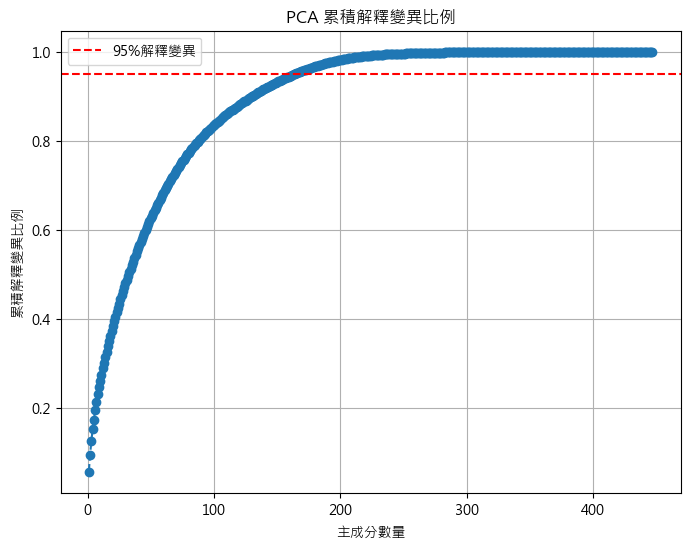

保留至少95%變異需要的主成分數量:164


In [65]:
secom = pd.read_csv(data_path, sep='\t')
X = secom.drop(columns=['Time', 'Pass/Fail'])

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = scaler.fit_transform(X_imp)

pca = PCA()
X_pca = pca.fit_transform(X_std)

explained_variance_ratio = pca.explained_variance_ratio_

cumulative_variance = np.cumsum(explained_variance_ratio)
print('累積解釋變異比例: ')
print(cumulative_variance)

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'o', linestyle = '--')
plt.xlabel('主成分數量')
plt.ylabel('累積解釋變異比例')
plt.title('PCA 累積解釋變異比例')
plt.axhline(y = 0.95, color = 'r', linestyle = '--', label = '95%解釋變異')
plt.legend()
plt.grid()
plt.show()

n_component_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f'保留至少95%變異需要的主成分數量:{n_component_95}')


累積解釋變異比例: 
[0.04792715 0.09229035 0.13255455 0.16874834 0.19941028 0.22825488
 0.25310421 0.27745788 0.30080607 0.32250503 0.34387546 0.36471358
 0.38534406 0.4040684  0.42244223 0.44029531 0.4575067  0.47451751
 0.49074172 0.50627268 0.52104388 0.5350831  0.54877693 0.56236206
 0.57546363 0.58841178 0.60101175 0.61328159 0.6254735  0.63746366
 0.64934685 0.66091039 0.67218822 0.6833749  0.69438317 0.70521352
 0.71562058 0.72595062 0.73615104 0.74626994 0.75604832 0.76578299
 0.77544208 0.78490309 0.79422346 0.80347078 0.81250569 0.82149418
 0.83019355 0.83855238 0.84685963 0.85494732 0.86297362 0.87076015
 0.87830866 0.88571319 0.8930027  0.8999966  0.90682128 0.9135162
 0.91998577 0.92630035 0.9324093  0.9381942  0.94386281 0.94931141
 0.95450765 0.95928502 0.96371935 0.96803317 0.97215078 0.97611904
 0.97985947 0.98298116 0.98587142 0.98849333 0.990821   0.99294435
 0.99475762 0.99640021 0.99753276 0.99820472 0.99859713 0.99897208
 0.99922541 0.99946295 0.99967199 0.99979544 0.99988

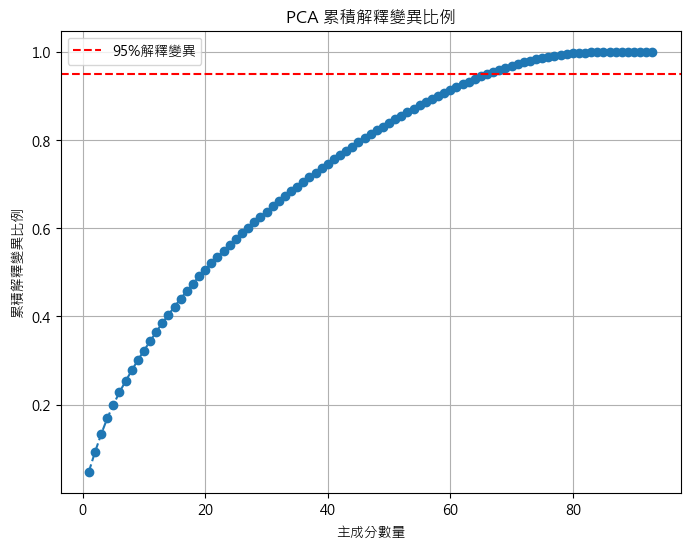

保留至少95%變異需要的主成分數量:67


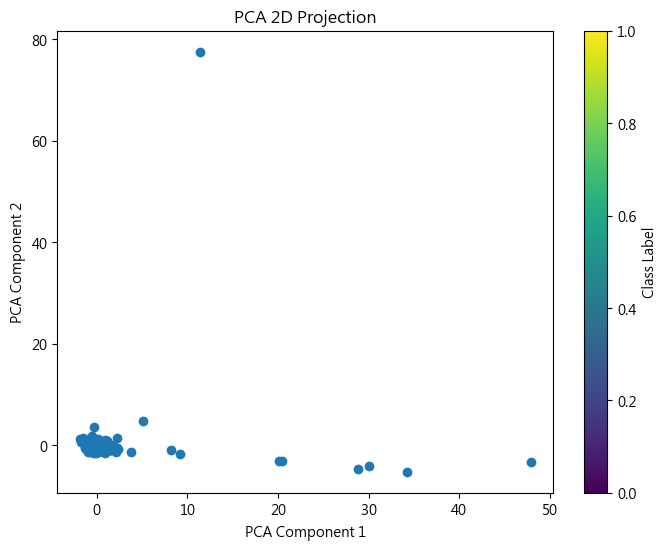

In [76]:
secom = pd.read_csv(data_path, sep='\t')

X = secom.drop(columns=['Time', 'Pass/Fail'])
y = secom['Pass/Fail'].replace({-1:0, 1:1}).astype(int)

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = pd.DataFrame(scaler.fit_transform(X_imp), columns=X.columns, index=X.index)

pca = PCA(n_components=0.9)
X_pca = pca.fit_transform(X_std)
X_pca_df = pd.DataFrame(X_pca, columns=[f'pc{i}' for i in range(1, X_pca.shape[1]+1)])

secom = pd.read_csv(data_path, sep='\t')
outlier = X_pca_df[(X_pca_df['pc1']>10)|(X_pca_df['pc2']>10)].index.tolist()

p_c_final_data = pd.read_csv(r'C:\Users\No\Documents\GitHub\psychic-spoon\0 Meeting\p=half_c=0_final.csv', sep='\t')
p_c_final_data_features = p_c_final_data['feature'][1:].to_list()

X = secom[p_c_final_data_features]

na_counts = X.isna().sum()
X = X.loc[:, na_counts <= 1000].copy()
uniq_counts = X.nunique(dropna=False)
X = X.loc[:, uniq_counts >= 10].copy()
X = X.loc[:, ~X.T.duplicated(keep='first')].copy()

imputer = KNNImputer(n_neighbors=10, weights='distance')
X_imp = pd.DataFrame(imputer.fit_transform(X), columns=X.columns, index=X.index)

scaler = StandardScaler()
X_std = scaler.fit_transform(X_imp)

pca = PCA()
X_pca = pca.fit_transform(X_std)

explained_variance_ratio = pca.explained_variance_ratio_

cumulative_variance = np.cumsum(explained_variance_ratio)
print('累積解釋變異比例: ')
print(cumulative_variance)

plt.figure(figsize=(8, 6))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, 'o', linestyle = '--')
plt.xlabel('主成分數量')
plt.ylabel('累積解釋變異比例')
plt.title('PCA 累積解釋變異比例')
plt.axhline(y = 0.95, color = 'r', linestyle = '--', label = '95%解釋變異')
plt.legend()
plt.grid()
plt.show()

n_component_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f'保留至少95%變異需要的主成分數量:{n_component_95}')

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1])
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA 2D Projection")
plt.colorbar(label="Class Label")  # 加上顏色對應的類別
plt.show()
